# Mental Health Model Experimentation

**Location:** `0 try/experiment.ipynb`

**Outputs to:** `../3-cicd/`

**Goal:** Find the best model, hyperparameters, and features

**Output:** `best_config.json` in `3-cicd/` folder for `train.py`

In [12]:
# Setup and imports
import numpy as np
import pandas as pd
import json
import re
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import make_scorer, fbeta_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.inspection import permutation_importance


import mlflow 
mlflow.set_tracking_uri("file:./mlruns")          
mlflow.set_experiment("mental-health-notebook")

pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')

OUTPUT_DIR = Path('../3-cicd')
OUTPUT_DIR.mkdir(exist_ok=True)

print('✓ Libraries imported')
print(f'✓ Output: {OUTPUT_DIR.absolute()}')

✓ Libraries imported
✓ Output: /Users/rociofaena/Documents/ML Ops/MLOPS-main/0-try/../3-cicd


In [13]:
# Load data
df = pd.read_csv('../data/raw/survey.csv')
print(f'Dataset: {df.shape}')
df.head()

Dataset: (1259, 27)


,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,remote_work,tech_company,benefits,care_options,wellness_program,seek_help,anonymity,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,No,Yes,Yes,Not sure,No,Yes,Yes,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,No,No,Don't know,No,Don't know,Don't know,Don't know,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,No,Yes,No,No,No,No,Don't know,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,No,Yes,No,Yes,No,No,No,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,Yes,Yes,Yes,No,Don't know,Don't know,Don't know,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


In [14]:
# Preprocessing
def clean_gender(gen):
    s = str(gen).strip().lower()
    s = re.sub(r'[\W_]+', ' ', s).strip()
    if s in {'m','male','man','make','mal','malr','msle','masc','mail','boy'}:
        return 'Male'
    if s in {'f','female','woman','femake','femail','femme','girl'}:
        return 'Female'
    return 'Other'

target_col = 'treatment'
features_to_drop = ['Timestamp','Country','state','comments',target_col]

y = df[target_col].map({'Yes':1,'No':0}).astype(int)
X = df.drop(columns=features_to_drop)
if 'Gender' in X.columns:
    X['Gender'] = X['Gender'].apply(clean_gender)

print(f'Features: {X.shape[1]}')
print(f'Samples: {X.shape[0]}')
print('\nTarget distribution:')
print(y.value_counts(normalize=True))

Features: 22
Samples: 1259

Target distribution:
treatment
1    0.505957
0    0.494043
Name: proportion, dtype: float64


In [15]:
# Define models
models_to_test = {
    'LogisticRegression': {
        'model': LogisticRegression(solver='liblinear',max_iter=5000,random_state=42),
        'params': {'C':1.0,'penalty':'l2'}
    },
    'RandomForest': {
        'model': RandomForestClassifier(random_state=42),
        'params': {'n_estimators':300,'max_depth':10,'min_samples_split':2,'class_weight':'balanced'}
    },
    'XGBoost': {
        'model': XGBClassifier(random_state=42),
        'params': {'n_estimators':400,'max_depth':6,'learning_rate':0.01,'subsample':0.8,'colsample_bytree':1.0,'scale_pos_weight':1.26}
    }
}

print('Models to test:')
for name in models_to_test:
    print(f'  - {name}')

Models to test:
  - LogisticRegression
  - RandomForest
  - XGBoost


In [16]:
# Build preprocessor
def build_preprocessor(X):
    num_cols = X.select_dtypes(include=['number','bool']).columns.tolist()
    cat_cols = X.select_dtypes(include=['object','category']).columns.tolist()
    num_pipe = Pipeline([('impute',SimpleImputer(strategy='median')),('scale',StandardScaler())])
    cat_pipe = Pipeline([('impute',SimpleImputer(strategy='most_frequent')),('onehot',OneHotEncoder(handle_unknown='ignore',sparse_output=False))])
    return ColumnTransformer([('num',num_pipe,num_cols),('cat',cat_pipe,cat_cols)],remainder='drop')

preprocessor = build_preprocessor(X)
print('✓ Preprocessor ready')

✓ Preprocessor ready


In [17]:
# Cross-validation
print('='*70)
print('CROSS-VALIDATION')
print('='*70)

cv = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
scoring = {'recall':'recall','precision':'precision','f1':'f1','roc_auc':'roc_auc','fbeta':make_scorer(fbeta_score,beta=1.5)}

results = []
for name,config in models_to_test.items():
    print(f'\n🔄 {name}...')
    model = config['model']
    model.set_params(**config['params'])
    pipe = Pipeline([('preprocess',preprocessor),('model',model)])
    cv_results = cross_validate(pipe,X,y,cv=cv,scoring=scoring,n_jobs=-1,return_train_score=False)
    result = {
        'model':name,
        'recall_mean':cv_results['test_recall'].mean(),
        'recall_std':cv_results['test_recall'].std(),
        'precision_mean':cv_results['test_precision'].mean(),
        'precision_std':cv_results['test_precision'].std(),
        'f1_mean':cv_results['test_f1'].mean(),
        'f1_std':cv_results['test_f1'].std(),
        'fbeta_mean':cv_results['test_fbeta'].mean(),
        'fbeta_std':cv_results['test_fbeta'].std(),
        'roc_auc_mean':cv_results['test_roc_auc'].mean(),
        'roc_auc_std':cv_results['test_roc_auc'].std()
    }
    results.append(result)
    print(f"  Recall:    {result['recall_mean']:.3f} ± {result['recall_std']:.3f}")
    print(f"  Precision: {result['precision_mean']:.3f} ± {result['precision_std']:.3f}")
    print(f"  F-beta:    {result['fbeta_mean']:.3f} ± {result['fbeta_std']:.3f}")

CROSS-VALIDATION

🔄 LogisticRegression...
  Recall:    0.741 ± 0.022
  Precision: 0.749 ± 0.024
  F-beta:    0.743 ± 0.019

🔄 RandomForest...
  Recall:    0.746 ± 0.033
  Precision: 0.764 ± 0.029
  F-beta:    0.751 ± 0.031

🔄 XGBoost...
  Recall:    0.783 ± 0.027
  Precision: 0.733 ± 0.016
  F-beta:    0.767 ± 0.022



RESULTS
             model  recall_mean  precision_mean  fbeta_mean
           XGBoost     0.783354        0.732801    0.766937
      RandomForest     0.745743        0.763736    0.751098
LogisticRegression     0.741043        0.748599    0.743138

🏆 Best: XGBoost


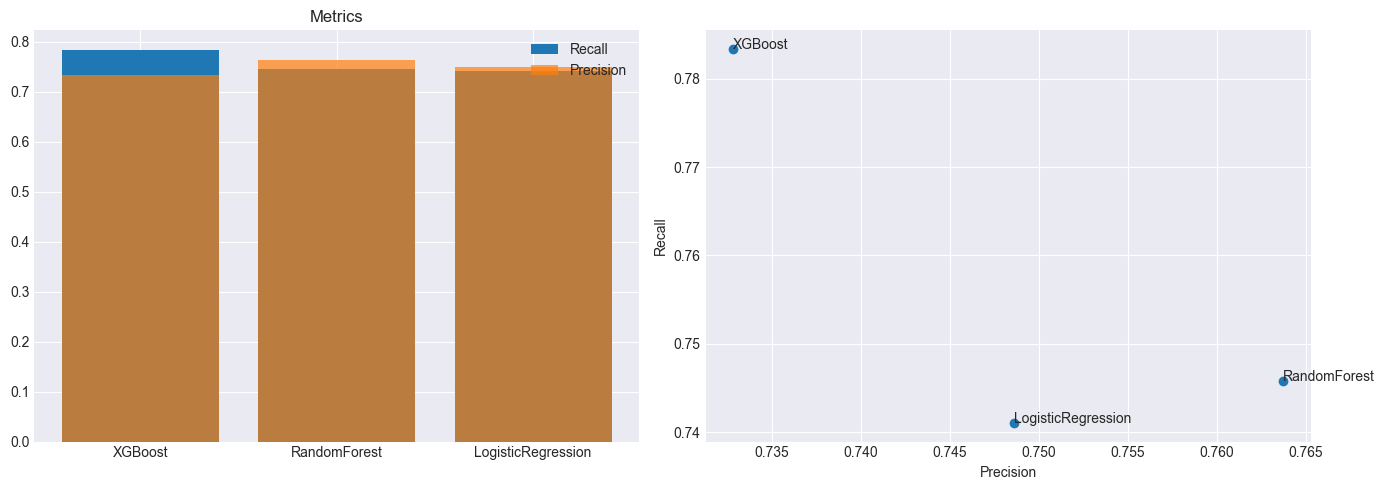

✓ Saved: ../3-cicd/model_comparison.png


In [18]:
# Results
results_df = pd.DataFrame(results).sort_values('fbeta_mean',ascending=False)
print('\n'+'='*70)
print('RESULTS')
print('='*70)
print(results_df[['model','recall_mean','precision_mean','fbeta_mean']].to_string(index=False))
best_model_name = results_df.iloc[0]['model']
print(f'\n🏆 Best: {best_model_name}')

# Plot
fig,ax = plt.subplots(1,2,figsize=(14,5))
x = np.arange(len(results_df))
ax[0].bar(x,results_df['recall_mean'],label='Recall')
ax[0].bar(x,results_df['precision_mean'],alpha=0.7,label='Precision')
ax[0].set_xticks(x)
ax[0].set_xticklabels(results_df['model'])
ax[0].legend()
ax[0].set_title('Metrics')
ax[1].scatter(results_df['precision_mean'],results_df['recall_mean'])
for _,row in results_df.iterrows():
    ax[1].annotate(row['model'],(row['precision_mean'],row['recall_mean']))
ax[1].set_xlabel('Precision')
ax[1].set_ylabel('Recall')
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'model_comparison.png',dpi=150)
plt.show()
print(f'✓ Saved: {OUTPUT_DIR}/model_comparison.png')

In [19]:
# Feature importance
print('='*70)
print('FEATURE SELECTION')
print('='*70)

best_config = models_to_test[best_model_name]
best_model = best_config['model']
best_model.set_params(**best_config['params'])

X_train,X_val,y_train,y_val = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
pipe = Pipeline([('preprocess',preprocessor),('model',best_model)])
pipe.fit(X_train,y_train)

perm = permutation_importance(pipe.named_steps['model'],pipe.named_steps['preprocess'].transform(X_val),y_val,n_repeats=10,random_state=42,n_jobs=-1)

try:
    feat_names = pipe.named_steps['preprocess'].get_feature_names_out()
except:
    feat_names = [f'f_{i}' for i in range(len(perm.importances_mean))]

orig_imp = {}
for col in X.columns:
    imp = [perm.importances_mean[i] for i,f in enumerate(feat_names) if col.lower() in f.lower()]
    orig_imp[col] = max(imp) if imp else 0.0

imp_df = pd.DataFrame([{'feature':k,'importance':v} for k,v in orig_imp.items()]).sort_values('importance',ascending=False)
print('\nTop features:')
print(imp_df.head(10).to_string(index=False))

FEATURE SELECTION

Top features:
                feature  importance
         work_interfere    0.075794
           care_options    0.036905
         family_history    0.036111
                 Gender    0.007937
                  leave    0.007540
             supervisor    0.006746
           no_employees    0.004365
              coworkers    0.003571
mental_health_interview    0.003175
       wellness_program    0.002381



Threshold: 0.001
Selected: 13
Removed: 9

Removed: ['mental_vs_physical', 'tech_company', 'remote_work', 'obs_consequence', 'phys_health_interview', 'anonymity', 'seek_help', 'benefits', 'Age']


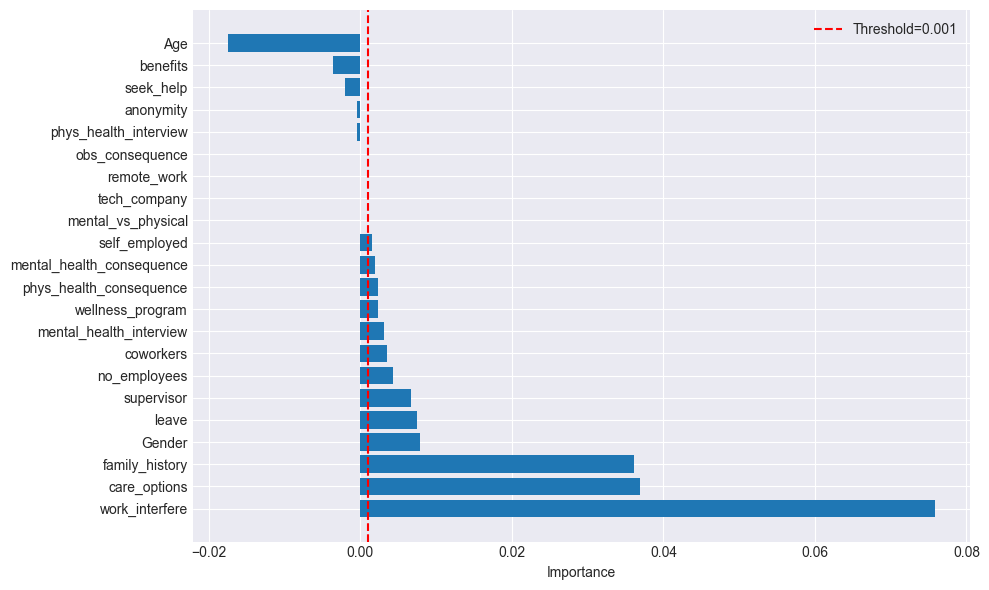

✓ Saved: ../3-cicd/feature_importance.png


In [20]:
# Feature selection
thresh = 0.001
selected = imp_df[imp_df['importance']>thresh]['feature'].tolist()
removed = imp_df[imp_df['importance']<=thresh]['feature'].tolist()

print(f'\nThreshold: {thresh}')
print(f'Selected: {len(selected)}')
print(f'Removed: {len(removed)}')
if removed:
    print(f'\nRemoved: {removed}')

plt.figure(figsize=(10,6))
plt.barh(imp_df['feature'],imp_df['importance'])
plt.axvline(thresh,color='red',linestyle='--',label=f'Threshold={thresh}')
plt.xlabel('Importance')
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR/'feature_importance.png',dpi=150)
plt.show()
print(f'✓ Saved: {OUTPUT_DIR}/feature_importance.png')

In [21]:
# Final evaluation
X_sel = X[selected].copy()
pipe_final = Pipeline([('preprocess',build_preprocessor(X_sel)),('model',best_model)])
cv_final = cross_validate(pipe_final,X_sel,y,cv=cv,scoring=scoring,n_jobs=-1)

print('\nFinal CV:')
print(f"  Recall:    {cv_final['test_recall'].mean():.3f}")
print(f"  Precision: {cv_final['test_precision'].mean():.3f}")
print(f"  F-beta:    {cv_final['test_fbeta'].mean():.3f}")


Final CV:
  Recall:    0.788
  Precision: 0.745
  F-beta:    0.774


In [22]:
# Save config
config = {
    'model':{'name':best_model_name,'class':best_model_name,'hyperparameters':best_config['params']},
    'features':{'selected':selected,'removed':removed,'importance_threshold':thresh},
    'performance':{
        'cv_recall_mean':float(cv_final['test_recall'].mean()),
        'cv_recall_std':float(cv_final['test_recall'].std()),
        'cv_precision_mean':float(cv_final['test_precision'].mean()),
        'cv_precision_std':float(cv_final['test_precision'].std()),
        'cv_f1_mean':float(cv_final['test_f1'].mean()),
        'cv_f1_std':float(cv_final['test_f1'].std()),
        'cv_fbeta_mean':float(cv_final['test_fbeta'].mean()),
        'cv_fbeta_std':float(cv_final['test_fbeta'].std()),
        'cv_roc_auc_mean':float(cv_final['test_roc_auc'].mean()),
        'cv_roc_auc_std':float(cv_final['test_roc_auc'].std())
    },
    'targets':{'min_recall':0.80,'min_precision':0.65,'beta':1.5}
}

with mlflow.start_run(run_name=f"notebook_{best_model_name}"):
    # hiperparámetros
    mlflow.log_param("model_name", best_model_name)
    for k, v in best_config["params"].items():
        mlflow.log_param(f"hp_{k}", v)
    mlflow.log_param("n_features", len(selected))
    mlflow.log_param("importance_threshold", float(thresh))

    # métricas de CV
    for metric_name, value in config["performance"].items():
        mlflow.log_metric(metric_name, float(value))

# seguir guardando el config en 3-cicd como antes
path = OUTPUT_DIR/'best_config.json'
with open(path,'w') as f:
    json.dump(config,f,indent=2)

print('='*70)
print('SAVED')
print('='*70)
print(f'✓ {path}')
print(f'\nModel: {best_model_name}')
print(f'Features: {len(selected)}')
print(f"Recall: {config['performance']['cv_recall_mean']:.1%}")
print(f"Precision: {config['performance']['cv_precision_mean']:.1%}")
print('\n🚀 Ready for: cd ../3-cicd && python train.py')

SAVED
✓ ../3-cicd/best_config.json

Model: XGBoost
Features: 13
Recall: 78.8%
Precision: 74.5%

🚀 Ready for: cd ../3-cicd && python train.py
